# STEP 4 — Safety Validation & Actionability (updated per Jack Denham's review)  
================================================================================  
Four changes from Jack's meeting notes, in the order he raised them:  
  
  #2 (fixed as a genuine bug, not a design tweak): the "already taking it?"  
  check was rebuilding baskets with the OLD calendar-week grain from before  
  the NHS-anchor redesign — completely disconnected from Step 2's actual  
  basket logic, and effectively behaving like a ~1-week lookback rather  
  than anything intentional. Replaced with a proper BACKWARD-looking  
  window anchored to each actual antecedent purchase occurrence, default  
  LOOKBACK_DAYS=30 ("a month", per Jack). Verified against hand-crafted  
  cases: a prior purchase 20 days before an anchor counts as already-  
  established, one 50 days before doesn't, and a purchase AFTER the  
  anchor never counts (that's Step 2's forward window, a different thing).  
  
  #3: precise severe-interaction reporting — not just "0% flagged" but  
  what fraction of rows have the field populated at all, so the finding  
  is "the field is fully populated but consistently N" rather than  
  "the field might just be empty/unused."  
  
  #4: reach + actionability — for the top rules by LIFT, compute how many  
  unique customers currently qualify as a target (bought the antecedent  
  within a recent window, don't yet have the consequent) and output an  
  actual CustomerKey list per rule, not just a rule-level statistic.  
  
  #5: rules grouped by BNF chapter of the antecedent NHS product, with a  
  bar chart — re-added after being dropped in an earlier pipeline  
  redesign.  
  
Input:  
  - market_basket_otc_rules.parquet (Step 2)  
  - clean_transactions_all_drugs.parquet (Step 1)


No EDW authentication needed — runs entirely off Step 1/2's saved parquet files.

In [5]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("step4_figures")
FIG_DIR.mkdir(exist_ok=True)

### CONFIG

In [6]:
LOOKBACK_DAYS = 30           # Jack: "increase the window to a month"
RECENT_WINDOW_DAYS = 90      # window for "reach" — customers considered a
                               # live target if they bought the antecedent
                               # in the last N days
TOP_N_RULES_FOR_REACH = 20   # how many top-by-lift rules to compute reach for
ALREADY_ESTABLISHED_THRESHOLD = 0.3

### PART A — Load

In [7]:
otc_rules = pd.read_parquet("market_basket_otc_rules.parquet")
transactions = pd.read_parquet("clean_transactions_all_drugs.parquet")
transactions["dispense_date_created"] = pd.to_datetime(transactions["dispense_date_created"])

print(f"[A] Loaded {len(otc_rules):,} OTC rules and {len(transactions):,} transaction rows")

def _to_tuple(x):
    if isinstance(x, (list, np.ndarray)):
        return tuple(x)
    return tuple(x) if not isinstance(x, tuple) else x

otc_rules["antecedents"] = otc_rules["antecedents"].apply(_to_tuple)
otc_rules["consequents"] = otc_rules["consequents"].apply(_to_tuple)

[A] Loaded 119 OTC rules and 67,124,000 transaction rows


### PART B — "Already taking it?" check — FIXED per Jack's bug flag

In [8]:
def already_established_check(antecedent, consequent, transactions_df, lookback_days=30):
    """
    For each occurrence of a customer buying the antecedent (NHS) product,
    checks whether they ALREADY had the full consequent set in the
    lookback_days BEFORE that specific purchase occurrence — not a
    calendar-week bucket, not "ever", but a real backward-looking window
    tied to each actual anchor date. See module docstring for the
    hand-verified test cases behind this logic.
    """
    antecedent_set = set(antecedent)
    consequent_set = set(consequent)


    ant_rows = transactions_df[transactions_df["ProductKey"].isin(antecedent_set)]
    anchors = ant_rows[["CustomerKey", "dispense_date_created"]].drop_duplicates()
    anchors = anchors.rename(columns={"dispense_date_created": "anchor_date"})

    if len(anchors) == 0:
        return pd.Series({
            "n_antecedent_occurrences": 0, "n_already_established": 0,
            "n_genuine_opportunity": 0, "pct_already_established": np.nan,
        })

    cons_rows = transactions_df[transactions_df["ProductKey"].isin(consequent_set)][
        ["CustomerKey", "ProductKey", "dispense_date_created"]
    ].rename(columns={"dispense_date_created": "cons_date", "ProductKey": "cons_product"})

    merged = anchors.merge(cons_rows, on="CustomerKey", how="left")
    merged["in_lookback"] = (
        merged["cons_date"].notna()
        & (merged["cons_date"] < merged["anchor_date"])
        & (merged["cons_date"] >= merged["anchor_date"] - pd.Timedelta(days=lookback_days))
    )

    established = (
        merged[merged["in_lookback"]]
        .groupby(["CustomerKey", "anchor_date"])["cons_product"]
        .apply(lambda s: consequent_set.issubset(set(s)))
    )
    anchors_idx = anchors.set_index(["CustomerKey", "anchor_date"]).index
    established = established.reindex(anchors_idx, fill_value=False)

    n_total = len(established)
    n_already = int(established.sum())
    return pd.Series({
        "n_antecedent_occurrences": n_total,
        "n_already_established": n_already,
        "n_genuine_opportunity": n_total - n_already,
        "pct_already_established": n_already / n_total if n_total else np.nan,
    })

print(f"[B] Running 'already taking it?' check per rule "
      f"(lookback_days={LOOKBACK_DAYS}, {len(otc_rules)} rules)")

established_results = otc_rules.apply(
    lambda r: already_established_check(r["antecedents"], r["consequents"], transactions, LOOKBACK_DAYS),
    axis=1,
)
otc_rules = pd.concat([otc_rules, established_results], axis=1)
print(f"[B] Done. Mean 'already established' rate across rules: "
      f"{otc_rules['pct_already_established'].mean():.1%}")

[B] Running 'already taking it?' check per rule (lookback_days=30, 119 rules)
[B] Done. Mean 'already established' rate across rules: 11.5%


### PART C — Severe-interaction check, WITH Jack's precise field-population question answered explicitly

In [9]:
n_nonnull = transactions["severe_interaction_noted"].notna().sum()
print(f"\n[C] severe_interaction_noted field population: "
      f"{n_nonnull:,} / {len(transactions):,} rows non-null "
      f"({n_nonnull / len(transactions):.1%})")
print("[C] Value distribution (including nulls):")
print(transactions["severe_interaction_noted"].value_counts(dropna=False).to_string())

interaction_flag = transactions["severe_interaction_noted"].astype(str).str.upper() == "Y"
transactions["_interaction_flag"] = interaction_flag
n_flagged_total = interaction_flag.sum()
print(f"[C] Rows actually flagged Y: {n_flagged_total:,} "
      f"({n_flagged_total / len(transactions):.4%} of all rows)")

def interaction_check(antecedent, consequent, transactions_df):
    combo = set(antecedent) | set(consequent)
    combo_baskets = (
        transactions_df[transactions_df["ProductKey"].isin(combo)]
        .groupby(["CustomerKey"])["ProductKey"]
        .apply(lambda s: combo.issubset(set(s)))
    )
    combo_customers = set(combo_baskets[combo_baskets].index)
    if len(combo_customers) == 0:
        return pd.Series({"n_combo_dispenses": 0, "n_flagged_interactions": 0, "interaction_rate": np.nan})
    relevant_rows = transactions_df[
        transactions_df["ProductKey"].isin(combo)
        & transactions_df["CustomerKey"].isin(combo_customers)
    ]
    n_flagged = relevant_rows["_interaction_flag"].sum()
    return pd.Series({
        "n_combo_dispenses": len(relevant_rows),
        "n_flagged_interactions": int(n_flagged),
        "interaction_rate": n_flagged / len(relevant_rows) if len(relevant_rows) else np.nan,
    })

print("\n[C] Running empirical interaction check per rule")
interaction_results = otc_rules.apply(
    lambda r: interaction_check(r["antecedents"], r["consequents"], transactions), axis=1,
)
otc_rules = pd.concat([otc_rules, interaction_results], axis=1)
n_any_flagged = (otc_rules["n_flagged_interactions"] > 0).sum()
print(f"[C] {n_any_flagged} / {len(otc_rules)} rules have at least one flagged interaction event")


[C] severe_interaction_noted field population: 67,124,000 / 67,124,000 rows non-null (100.0%)
[C] Value distribution (including nulls):
N    67124000
[C] Rows actually flagged Y: 0 (0.0000% of all rows)

[C] Running empirical interaction check per rule
[C] 0 / 119 rules have at least one flagged interaction event


### PART D — Substitution filter (unchanged from previous version)

In [10]:
def normalize_drug_name(name):
    return re.sub(r"\[.*?\]", "", name).strip().upper()

def is_substitution(antecedent_names, consequent_names):
    ant_normalized = {normalize_drug_name(n) for n in antecedent_names.split(", ")}
    cons_normalized = {normalize_drug_name(n) for n in consequent_names.split(", ")}
    return len(ant_normalized & cons_normalized) > 0

otc_rules["is_substitution"] = otc_rules.apply(
    lambda r: is_substitution(r["antecedent_names"], r["consequent_names"]), axis=1
)
print(f"\n[D] Substitution rules (same drug, different brand/pack): "
      f"{otc_rules['is_substitution'].sum()} / {len(otc_rules)}")


[D] Substitution rules (same drug, different brand/pack): 0 / 119


### PART E — Final curated tables

In [11]:
clean_mask = (
    (otc_rules["n_flagged_interactions"] == 0)
    & (otc_rules["is_substitution"] == False)
)

best_per_product = (
    otc_rules[clean_mask]
    .sort_values("n_genuine_opportunity", ascending=False)
    .groupby("consequent_names")
    .first()
    .reset_index()
    [["consequent_names", "antecedent_names", "support", "confidence",
      "lift", "pct_already_established", "n_genuine_opportunity"]]
)
print("\n=== Table: Best rule per distinct OTC product ===")
print(best_per_product.to_string(index=False))
best_per_product.to_csv("best_rule_per_product.csv", index=False)

genuine_opportunity_rules = otc_rules[
    clean_mask & (otc_rules["pct_already_established"] <= ALREADY_ESTABLISHED_THRESHOLD)
].sort_values("n_genuine_opportunity", ascending=False)

print(f"\n=== Table: Rules with <= {ALREADY_ESTABLISHED_THRESHOLD:.0%} already-established "
      f"({len(genuine_opportunity_rules):,} / {len(otc_rules):,} rules pass) ===")
print(
    genuine_opportunity_rules[
        ["antecedent_names", "consequent_names", "support", "confidence", "lift",
         "pct_already_established", "n_genuine_opportunity"]
    ].to_string(index=False)
)
genuine_opportunity_rules.to_csv("final_recommendations_genuine_opportunity.csv", index=False)


=== Table: Best rule per distinct OTC product ===
                                             consequent_names                                                          antecedent_names  support  confidence       lift  pct_already_established  n_genuine_opportunity
                   ADCAL -D3 chewable tablet fruit [P2U] [56]                 ALENDRONIC ACID (AS SODIUM SALT) tablets 70mg [SOMEX] [4]  0.00008    0.333333  22.461815                 0.051340                 5026.0
               ASPIRIN dispersible tablet 75mg [ACTAVIS] [28]                                     ATORVASTATIN tablets 40mg [TEVA] [28]  0.00642    0.321000   1.892689                 0.071335               927893.0
                 ASPIRIN dispersible tablet 75mg [ASPAR] [28]                                  ROSUVASTATIN tablets 20mg [KRKA UK] [28]  0.00016    0.320000   4.907975                 0.081345                26483.0
                         ASPIRIN tablets 75mg [MEDREICH] [28]                        

### PART F — Reach + actionable customer lists (Jack's comment #4)

In [12]:
as_of_date = transactions["dispense_date_created"].max()

def compute_reach(antecedent, consequent, transactions_df, recent_window_days, as_of_date):
    """
    Reach = unique customers who bought the antecedent within the recent
    window and do NOT already have the consequent (checked across all
    time, conservatively — i.e. we don't re-recommend to anyone who's
    ever had it, not just recently).
    """
    antecedent_set = set(antecedent)
    consequent_set = set(consequent)
    cutoff = as_of_date - pd.Timedelta(days=recent_window_days)

    recent_ant = transactions_df[
        transactions_df["ProductKey"].isin(antecedent_set)
        & (transactions_df["dispense_date_created"] >= cutoff)
    ]
    candidates = set(recent_ant["CustomerKey"].unique())
    already_have = set(
        transactions_df[transactions_df["ProductKey"].isin(consequent_set)]["CustomerKey"].unique()
    )
    return candidates - already_have

top_by_lift = otc_rules[clean_mask].sort_values("lift", ascending=False).head(TOP_N_RULES_FOR_REACH)

print(f"\n[F] Computing reach for top {len(top_by_lift)} rules by lift "
      f"(recent_window_days={RECENT_WINDOW_DAYS})")

actionable_rows = []
reach_summary_rows = []
for _, r in top_by_lift.iterrows():
    targets = compute_reach(r["antecedents"], r["consequents"], transactions, RECENT_WINDOW_DAYS, as_of_date)
    reach_summary_rows.append({
        "antecedent_names": r["antecedent_names"], "consequent_names": r["consequent_names"],
        "lift": r["lift"], "reach": len(targets),
    })
    for ck in targets:
        actionable_rows.append({
            "antecedent_names": r["antecedent_names"], "consequent_names": r["consequent_names"],
            "lift": r["lift"], "reach": len(targets), "CustomerKey": ck,
        })

reach_summary = pd.DataFrame(reach_summary_rows).sort_values(["lift", "reach"], ascending=False)
print("\n=== Table: Lift + reach for top rules (prioritisation view) ===")
print(reach_summary.to_string(index=False))
reach_summary.to_csv("rules_lift_and_reach.csv", index=False)

actionable_df = pd.DataFrame(actionable_rows)
actionable_df.to_csv("actionable_customer_list.csv", index=False)
print(f"\n[F] Saved {len(actionable_df):,} (rule, CustomerKey) actionable rows -> "
      "actionable_customer_list.csv")


[F] Computing reach for top 20 rules by lift (recent_window_days=90)

=== Table: Lift + reach for top rules (prioritisation view) ===
                                                                    antecedent_names                                              consequent_names       lift  reach
                                      ONE-ALPHA capsules 250nanograms [NEON HC] [30]                            Renavit tablets [STAN PHARM] [100] 185.185185   1165
           ENSTILAR cutaneous foam 50micrograms/g + 500micrograms/g [LEO PHARMA] [1]                                CAPASAL shampoo [DERMAL] [250]  80.096115    281
                                               MOMETASONE cream 0.1% [ACTAVIS] [100]                              DERMOL 500 lotion [DERMAL] [500]  43.866062    509
                                                 LAMOTRIGINE tablets 50mg [P2U] [84]                             THIAMINE tablets 100mg [P2U] [28]  43.122035    240
                              SUNVENIZ X

### PART G — Group rules by BNF chapter of the antecedent NHS product (Jack's comment #5)


=== Table: Surviving rules by BNF chapter of antecedent NHS product ===
02    71
06    13
01     3
13     2
04     2
09     1
05     1


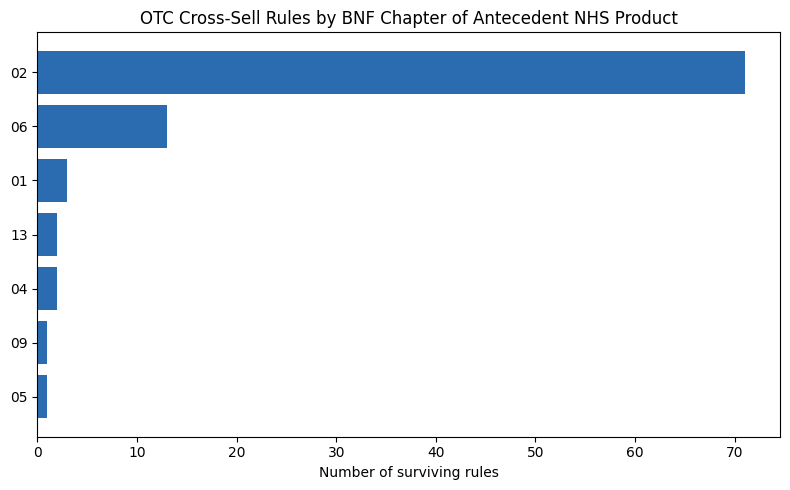


All Step 4 outputs saved. Figures in /mnt/batch/tasks/shared/LS_root/mounts/clusters/smrttempcins01/code/Users/FKSU/step4_figures


In [13]:
nhs_bnf_map = (
    transactions[transactions["LEGAL_CAT"] == "POM"]
    .drop_duplicates("ProductKey")
    .set_index("ProductKey")["ProductCodeLevel1"]
)

def get_bnf_chapter(antecedent_tuple):
    if len(antecedent_tuple) != 1:
        return None
    return nhs_bnf_map.get(antecedent_tuple[0], None)

otc_rules["antecedent_bnf_chapter"] = otc_rules["antecedents"].apply(get_bnf_chapter)

chapter_counts = (
    otc_rules[clean_mask]["antecedent_bnf_chapter"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n=== Table: Surviving rules by BNF chapter of antecedent NHS product ===")
print(chapter_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(chapter_counts.index.astype(str)[::-1], chapter_counts.values[::-1], color="#2b6cb0")
ax.set_xlabel("Number of surviving rules")
ax.set_title("OTC Cross-Sell Rules by BNF Chapter of Antecedent NHS Product")
plt.tight_layout()
plt.savefig(FIG_DIR / "rules_by_bnf_chapter.png", dpi=300)
plt.show()

print(f"\nAll Step 4 outputs saved. Figures in {FIG_DIR.resolve()}")